# Regression

### Load ins 

In [1]:
setwd("..")

In [2]:
source("src/functions_and_things.r")

load_libraries()

nyc_blue   = "#0062CF"
nyc_orange = "#EB6800"

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 


Warning message:
“package ‘zoo’ was built under R version 4.5.2”

Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Warning message:
“package ‘modelsummary’ was built under R version 4.5.2”
Warning message:
“package ‘fixest’ was built under R version

In [3]:
df <- read.csv("data/clean/queens.csv")

In [4]:
df |> 
    mutate(date = as.Date(date),
           day  = weekdays(date),
           weekend = ifelse(day == "Saturday" | day == "Sunday", 1, 0),
           weekend = as.factor(weekend),
           weekend = factor(weekend, labels = c("Weekday", "Weekend"))) -> df

head(df)

,X,date,ridership,min_temp,snow,rain,day,weekend
,<int>,<date>,<int>,<int>,<dbl>,<dbl>,<chr>,<fct>
1,1,2024-06-01,1414,62,0,0.00,Saturday,Weekend
2,2,2024-06-02,1068,62,0,0.00,Sunday,Weekend
3,3,2024-06-03,2337,66,0,0.02,Monday,Weekday
4,4,2024-06-04,2674,64,0,0.00,Tuesday,Weekday
5,5,2024-06-05,2545,63,0,0.04,Wednesday,Weekday
6,6,2024-06-06,2407,69,0,0.58,Thursday,Weekday


### Some plots

In [5]:
summary(df)

       X            date              ridership       min_temp    
 Min.   :  1   Min.   :2024-06-01   Min.   :   2   Min.   :12.00  
 1st Qu.:140   1st Qu.:2024-10-18   1st Qu.:1314   1st Qu.:38.00  
 Median :279   Median :2025-03-06   Median :2592   Median :50.00  
 Mean   :279   Mean   :2025-03-06   Mean   :2291   Mean   :49.49  
 3rd Qu.:418   3rd Qu.:2025-07-23   3rd Qu.:3108   3rd Qu.:63.00  
 Max.   :557   Max.   :2025-12-10   Max.   :3616   Max.   :78.00  
                                                   NA's   :191    
      snow              rain             day               weekend   
 Min.   :0.00000   Min.   :0.00000   Length:557         Weekday:398  
 1st Qu.:0.00000   1st Qu.:0.00000   Class :character   Weekend:159  
 Median :0.00000   Median :0.00000   Mode  :character                
 Mean   :0.05644   Mean   :0.08934                                   
 3rd Qu.:0.00000   3rd Qu.:0.03750                                   
 Max.   :3.10000   Max.   :1.49000          

In [6]:
df[which.max(df$ridership), ]

,X,date,ridership,min_temp,snow,rain,day,weekend
,<int>,<date>,<int>,<int>,<dbl>,<dbl>,<chr>,<fct>
550,550,2025-12-03,3616,NA,NA,NA,Wednesday,Weekday


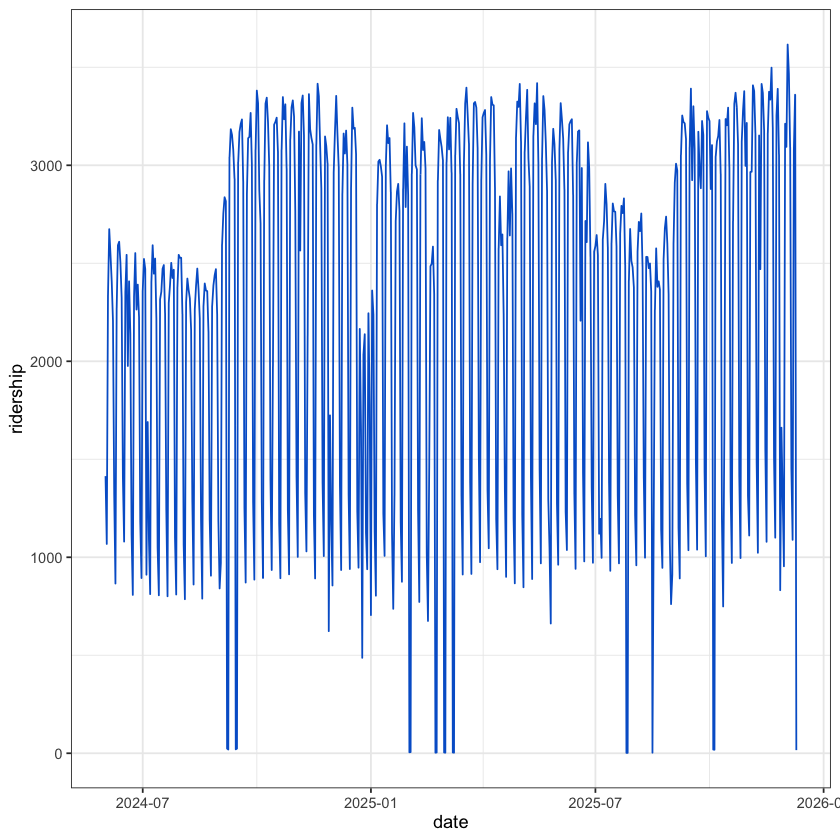

In [7]:
ggplot(data = df, aes(x = date, y = ridership)) + 
    geom_line(col = nyc_blue) + theme_bw()

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 191 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 191 rows containing missing values or values outside the scale range
(`geom_point()`).”


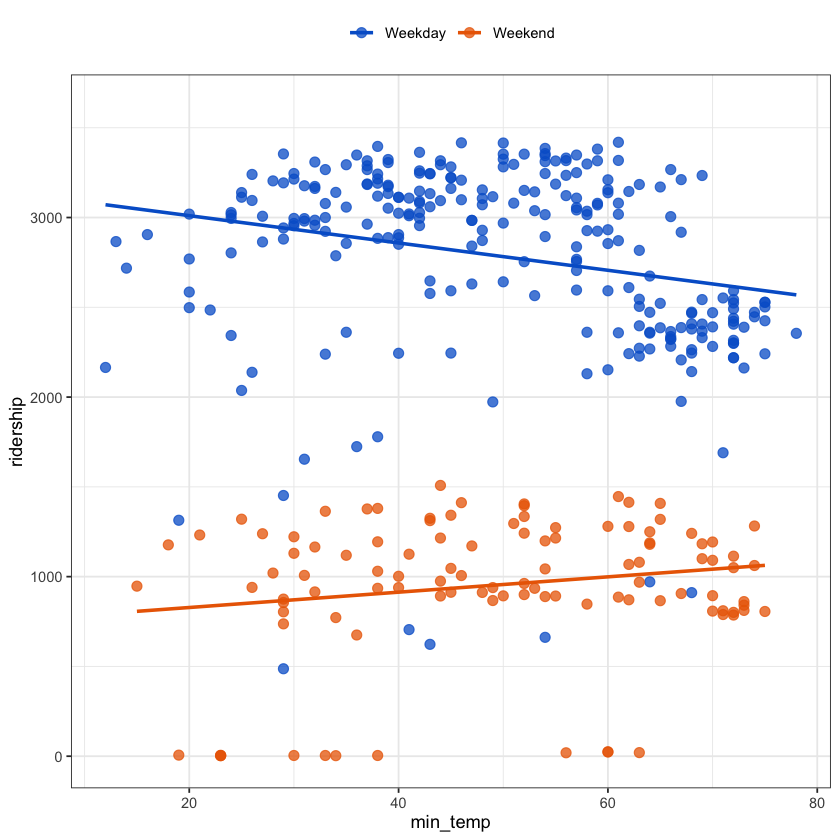

In [8]:
ggplot(data = df, aes(x = min_temp, y = ridership, color = weekend)) + 
    geom_point(size = 2.5, alpha = .75) + theme_bw() + 
    theme(legend.position = "top", legend.title = element_blank()) + 
    scale_color_manual(values = c("Weekend" = nyc_orange, "Weekday" = nyc_blue)) +
    geom_smooth(method = "lm", se = FALSE)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 191 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 191 rows containing missing values or values outside the scale range
(`geom_point()`).”


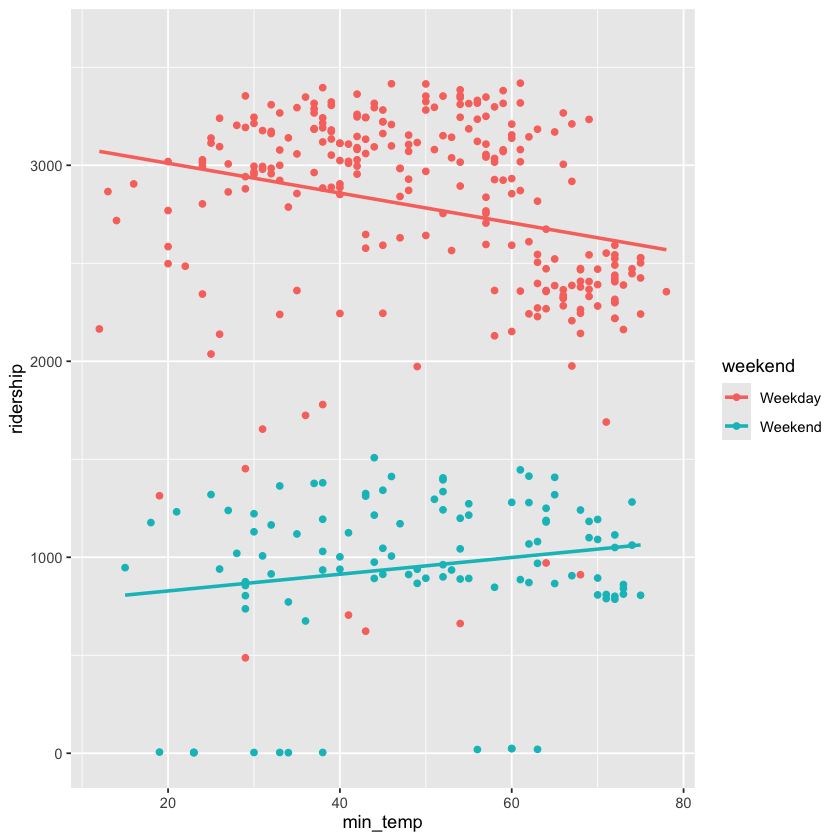

In [9]:
ggplot(data = df, aes(x = min_temp, y = ridership, color = weekend)) + 
    geom_point() + geom_smooth(method = "lm", se = FALSE)

#### Diagnostics

#### Evaluation